In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "hourly"
BENCHMARK = "RANDOM"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} {BENCH_PARAMS['metric_op']} {BENCH_PARAMS['threshold']}")
print(f"Sparsity min: {BENCH_PARAMS['sparsity_min']}")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: RANDOM
Aggregation: hourly
Threshold: max_acf <= 0.1
Sparsity min: 0.4
Sample size: 25 | Seed: 42


## 1 — Scoring

Compute max |ACF| across lags 1–168 on the raw series.
Series with very low autocorrelation (no detectable temporal structure) qualify as random.
If a score file already exists it is loaded from disk; otherwise `score_source` runs the full computation.

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/hourly/RANDOM_institutions.csv
Loading existing scores: scores/hourly/RANDOM_subnets.csv
Loading existing scores: scores/hourly/RANDOM_ips.csv

institutions: 283 series scored


,id_institution,ratio_active,max_acf
count,283.000,283.000,283.000
mean,142.233,0.989,0.502
std,82.480,0.073,0.216
min,0.000,0.134,0.013
25%,71.500,1.000,0.334
50%,142.000,1.000,0.524
75%,213.500,1.000,0.675
max,284.000,1.000,0.935



subnets: 548 series scored


,id_institution_subnet,ratio_active,max_acf
count,548.000,548.000,548.000
mean,273.500,0.961,0.454
std,158.338,0.143,0.249
min,0.000,0.064,0.002
25%,136.750,0.999,0.257
50%,273.500,1.000,0.447
75%,410.250,1.000,0.657
max,547.000,1.000,0.989



ips: 1000 series scored


,id_ip,ratio_active,max_acf
count,1000.000,1000.000,183.000
mean,860461.454,0.210,0.319
std,679140.522,0.308,0.268
min,11.000,0.000,0.000
25%,266825.500,0.011,0.095
50%,635072.500,0.074,0.242
75%,1629478.250,0.215,0.497
max,2044888.000,1.000,0.982


## 2 — Score distributions

Histogram of `max_acf` per level with the selection threshold overlaid.
Qualifying series fall at or below the threshold (≤ 0.1).

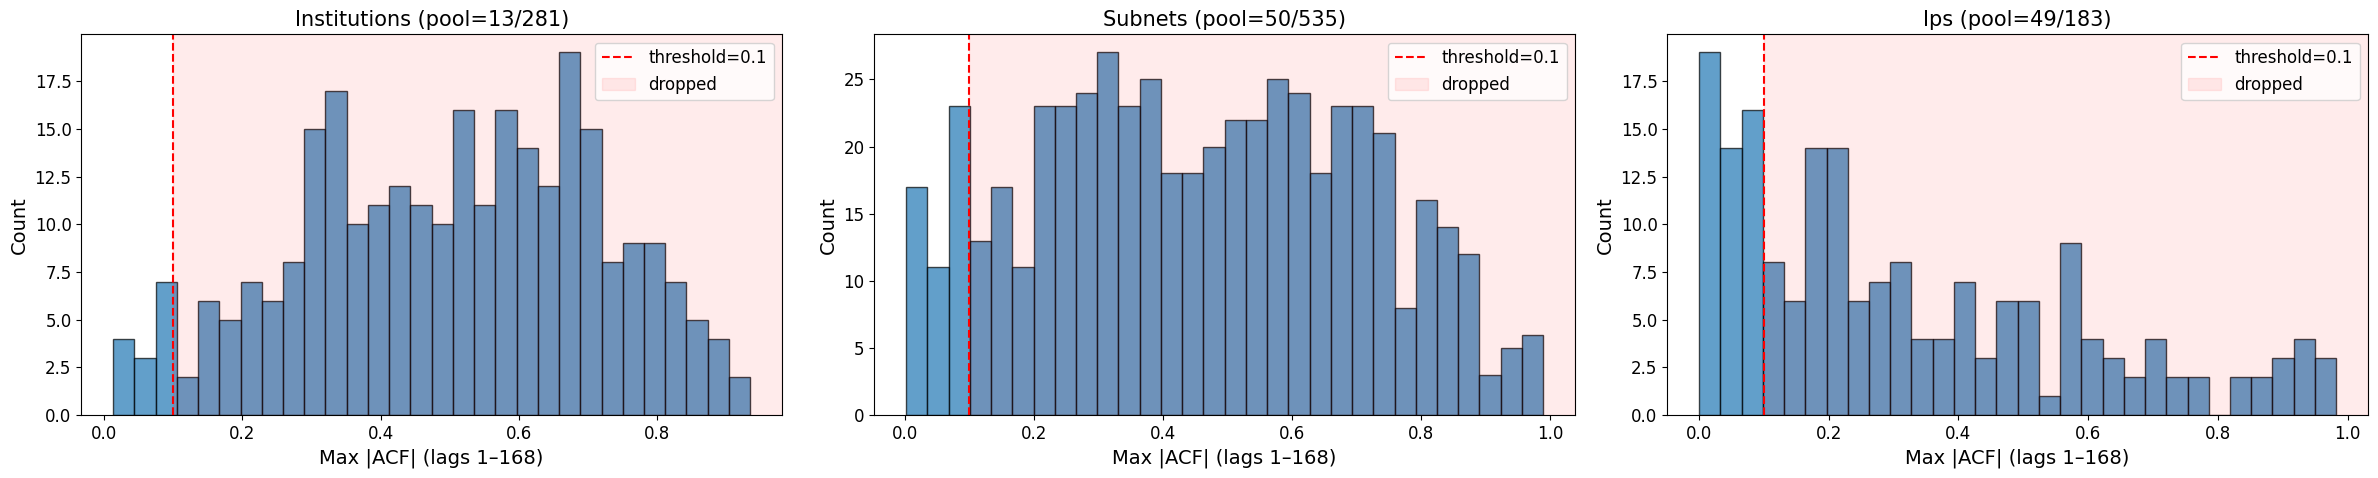

In [3]:
_smin = BENCH_PARAMS["sparsity_min"]
active_scores = {
    s: scores[s].dropna(subset=[BENCH_PARAMS["metric_col"]])
        .query("ratio_active >= @_smin")
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    metric_op=BENCH_PARAMS["metric_op"],
    xlabel="Max |ACF| (lags 1–168)",
)

## 3 — Selection

Apply sparsity filter, threshold filter (`max_acf ≤ 0.1`), then random sample from the qualifying pool.

In [4]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
    extra_info="Note: Institutions pool has fewer than 25 qualifying series",
)

  institutions: 281/283 pass sparsity, pool=13 — pool exhausted, taking all 13
  subnets: 535/548 pass sparsity, pool=50 — selected 25
  ips: 183/1000 pass sparsity, pool=49 — selected 25

RANDOM BENCHMARK - Selected Series
Threshold: max_acf >= 0.1
Selection: Random sample of 25 from qualifying pool
Note: Institutions pool has fewer than 25 qualifying series
Random seed: 42

institutions (13): [37, 83, 237, 256, 259, 264, 267, 270, 272, 277, 279, 280, 281]
  Pool size: 13
subnets (25): [23, 26, 41, 45, 46, 52, 57, 73, 76, 80, 89, 138, 185, 199, 300, 364, 404, 430, 461, 516, 522, 532, 535, 537, 542]
  Pool size: 50
ips (25): [10158, 10196, 39965, 119651, 125740, 151737, 156921, 170487, 195100, 215374, 290222, 330012, 363446, 376293, 381279, 471658, 476751, 482423, 488877, 650373, 659213, 792059, 1508962, 1604957, 1624160]
  Pool size: 49


## 4 — Detailed scores for selected series

In [5]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    df_s = scores[source]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("max_acf", ascending=True)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Institutions — selected series scores:


,id_institution,ratio_active,max_acf
171,280.0,0.981096,0.013127
123,281.0,0.999107,0.013489
17,256.0,0.997023,0.017972
174,267.0,0.962191,0.037529
249,279.0,0.988241,0.047612
56,37.0,0.999851,0.054292
49,264.0,0.661209,0.068628
107,259.0,0.999256,0.081659
43,270.0,0.999405,0.089052
178,277.0,0.666419,0.089232



Subnets — selected series scores:


,id_institution_subnet,ratio_active,max_acf
106,199.0,0.968294,0.003491
68,89.0,0.972313,0.007321
213,185.0,0.998511,0.014765
492,516.0,0.997023,0.017972
377,300.0,0.999702,0.029463
481,73.0,0.971867,0.033233
154,430.0,0.998511,0.034656
67,52.0,0.999851,0.034679
188,532.0,0.962191,0.037529
123,41.0,0.999851,0.039380



Ips — selected series scores:


,id_ip,ratio_active,max_acf
47,125740.0,0.944924,0.000246
891,330012.0,0.930188,0.000272
870,1604957.0,0.893421,0.001017
747,290222.0,0.998809,0.005155
418,170487.0,0.987347,0.009169
914,488877.0,0.423043,0.020926
762,39965.0,0.448943,0.022223
981,10196.0,0.827330,0.042184
131,1508962.0,0.513397,0.044311
215,792059.0,0.964870,0.046848


## 5 — Verification plots

For a few selected series per level: raw time series and ACF correlogram with 95% confidence interval.

In [6]:
scale = AGG_PARAMS["daily_period"] / 24
MAX_LAG = int(BENCH_PARAMS["max_lag_factor"] * scale)
ACF_THRESHOLD = BENCH_PARAMS["threshold"]


def plot_random_verification(df, id_col, ts_id, level_label):
    grp = df[df[id_col] == ts_id].reset_index(drop=True)
    t = grp["datetime"]
    y = grp["n_bytes"].astype(float).values

    acf_vals = acf(y, nlags=MAX_LAG, fft=True)
    max_acf = float(np.max(np.abs(acf_vals[1:])))
    n = len(y)
    ci = 1.96 / np.sqrt(n)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(t, y, linewidth=0.3, alpha=0.7)
    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)
    axes[0].set_title(f"{level_label} | ID = {int(ts_id)}  —  Raw n_bytes")
    axes[0].set_ylabel("n_bytes")
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[0].grid(True, alpha=0.3)

    lags = np.arange(1, len(acf_vals))
    axes[1].bar(lags, acf_vals[1:], width=1, alpha=0.7, color="steelblue")
    axes[1].axhline(ci, color="red", linestyle="--", alpha=0.5,
                    label=f"95% CI (\u00b1{ci:.3f})")
    axes[1].axhline(-ci, color="red", linestyle="--", alpha=0.5)
    axes[1].axhline(ACF_THRESHOLD, color="orange", linestyle=":", alpha=0.7,
                    label=f"threshold={ACF_THRESHOLD}")
    axes[1].axhline(-ACF_THRESHOLD, color="orange", linestyle=":", alpha=0.7)
    axes[1].set_title(f"ACF of n_bytes | max |ACF|={max_acf:.3f}")
    axes[1].set_ylabel("ACF")
    axes[1].set_xlabel("Lag (hours)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.63s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [272  37 277], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128
      

institutions (AGG_1_HOUR): 3 series loaded

INSTITUTIONS — verifying 3 series


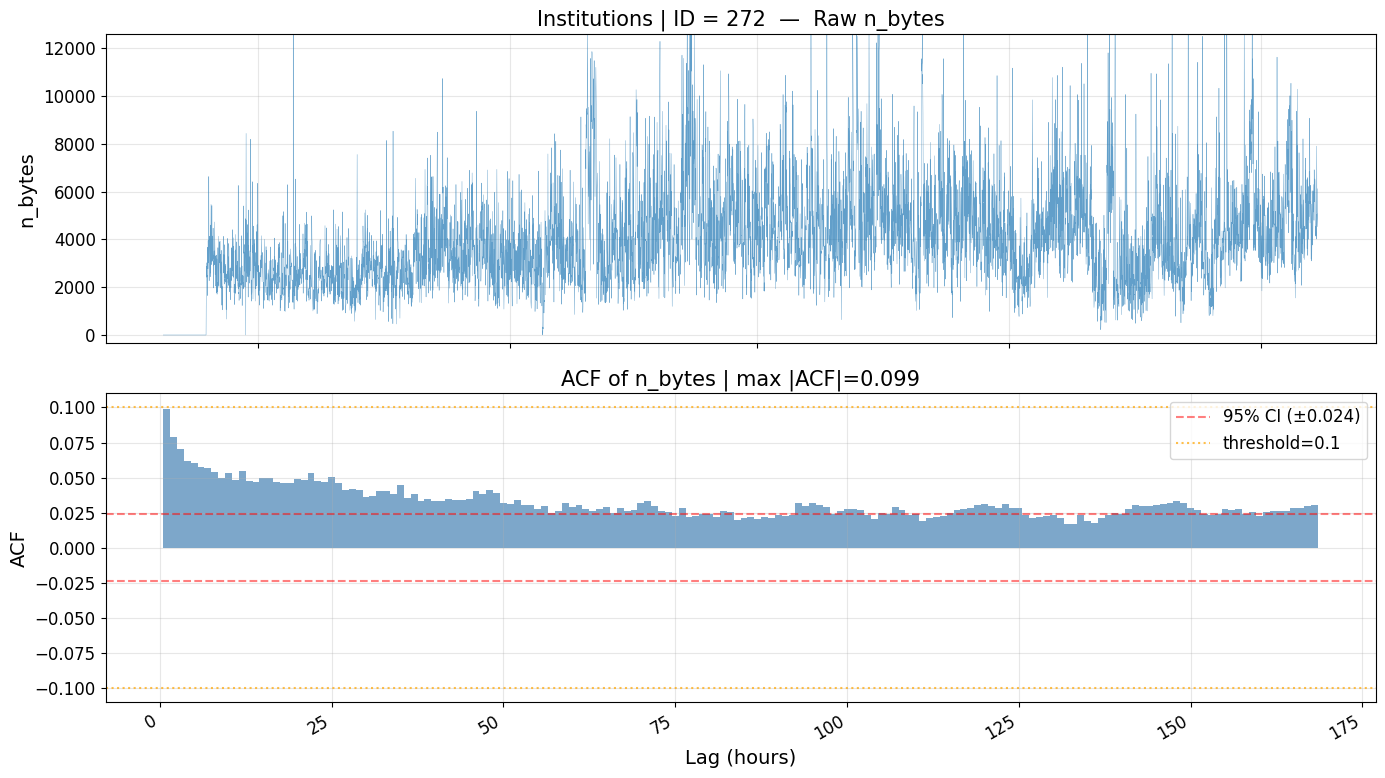

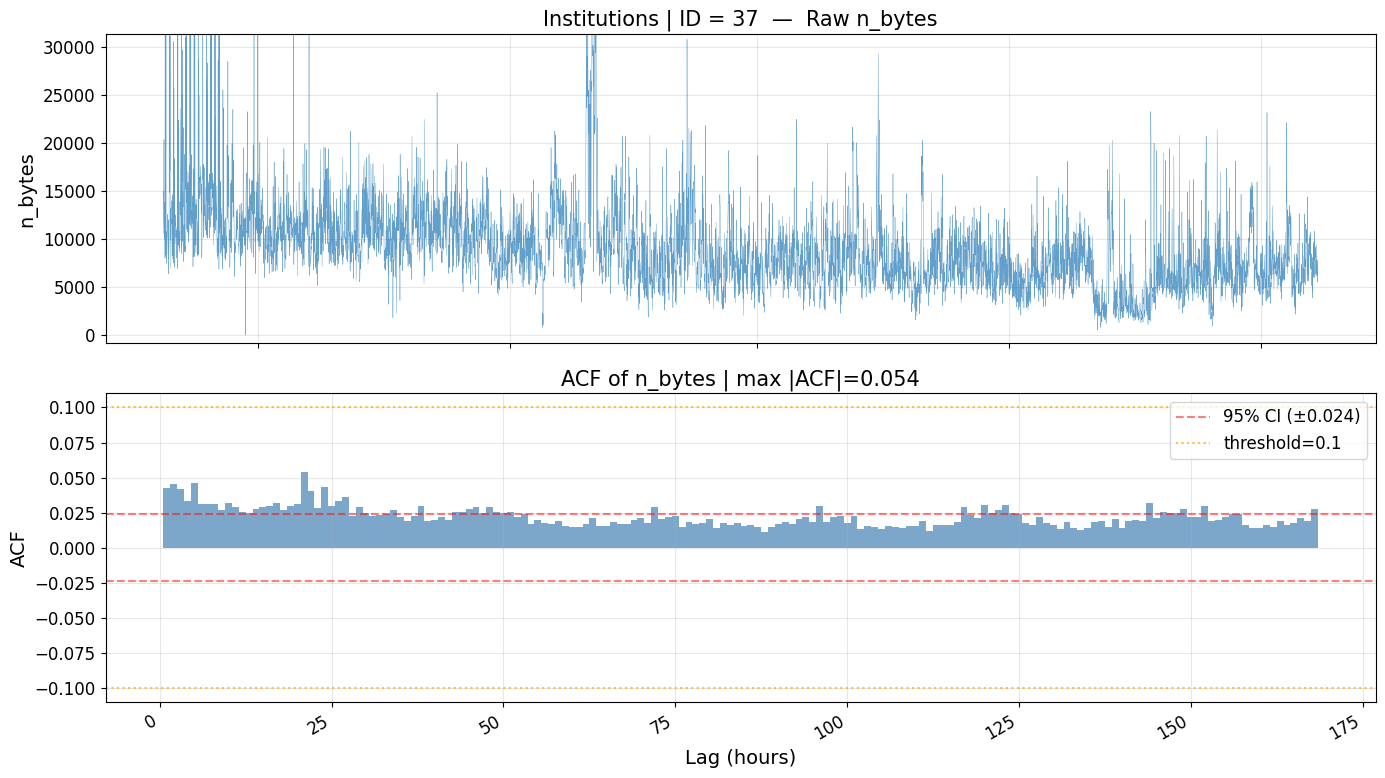

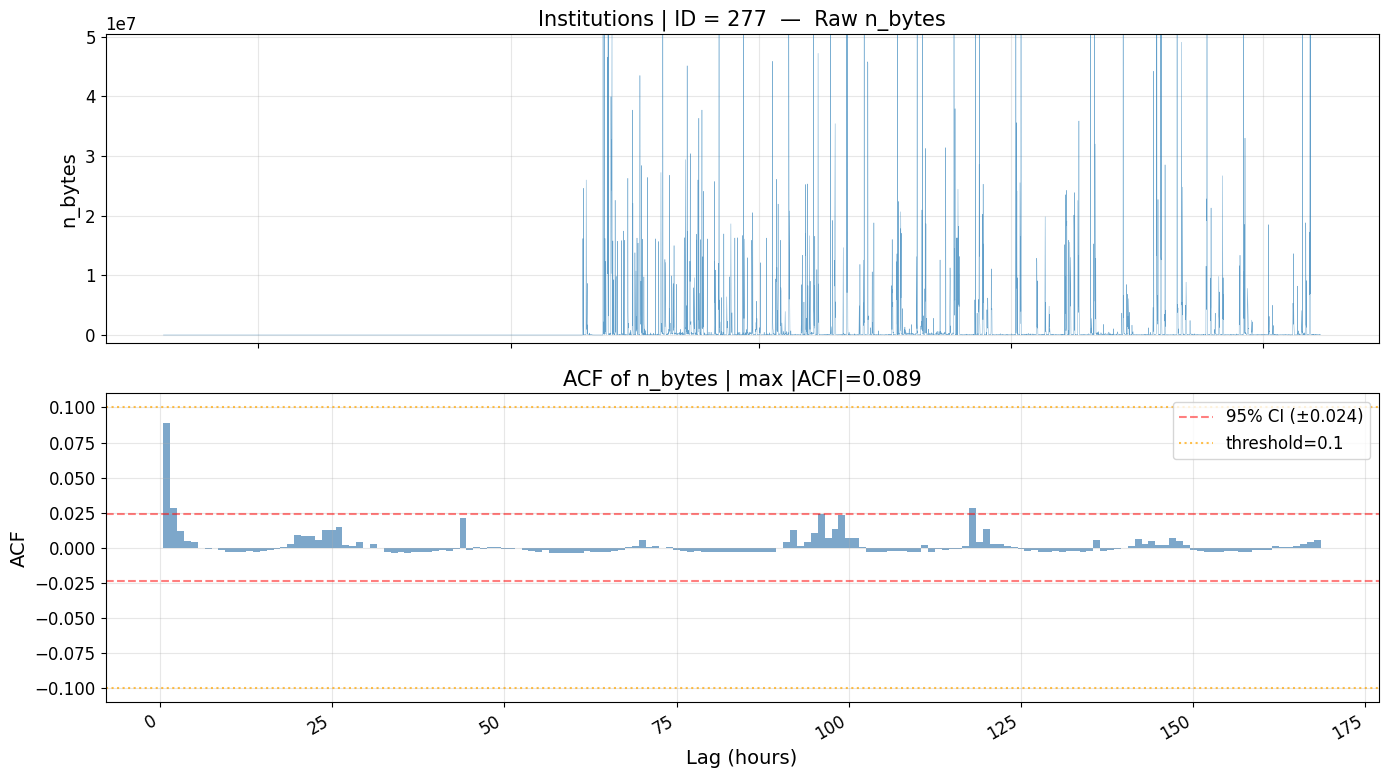

100%|████████████████████████████| 3/3 [00:07<00:00,  2.60s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 41 430 516], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128

subnets (AGG_1_HOUR): 3 series loaded

SUBNETS — verifying 3 series


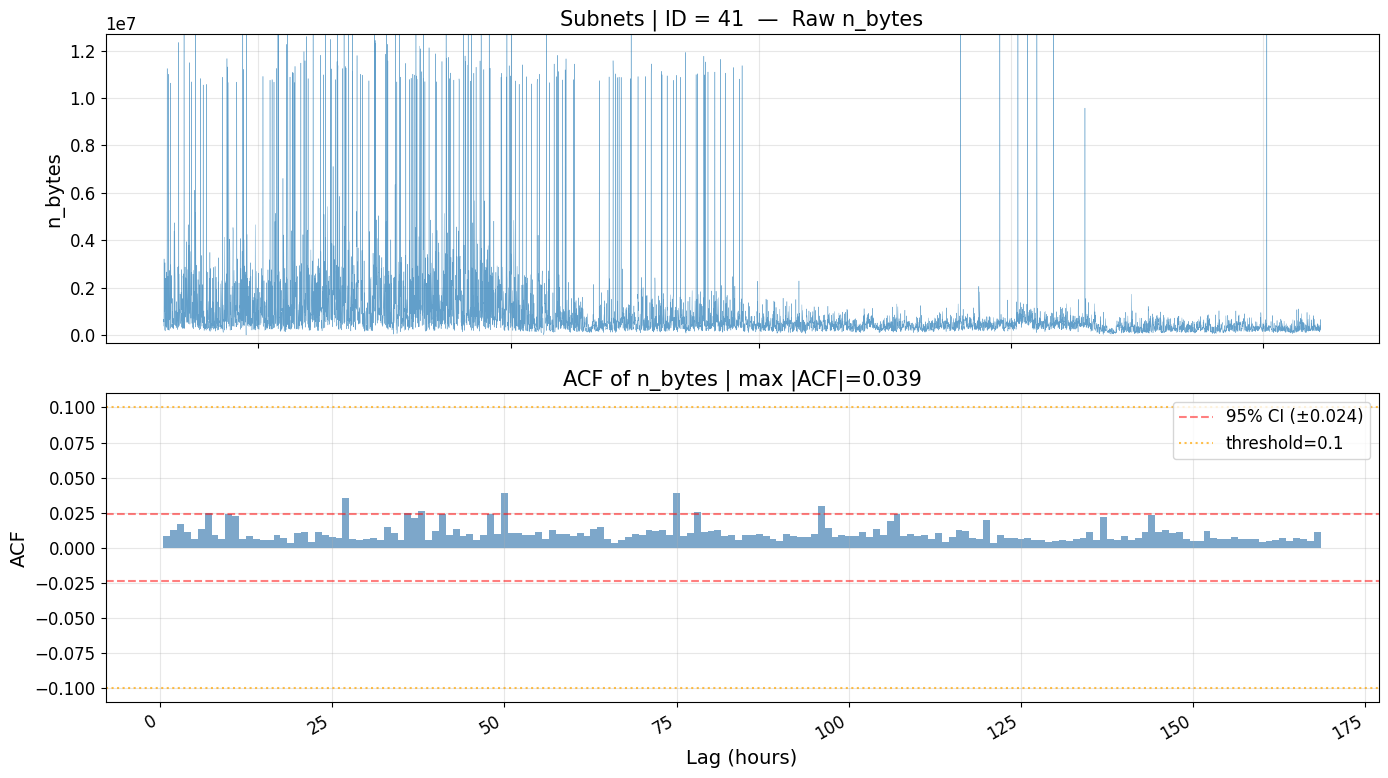

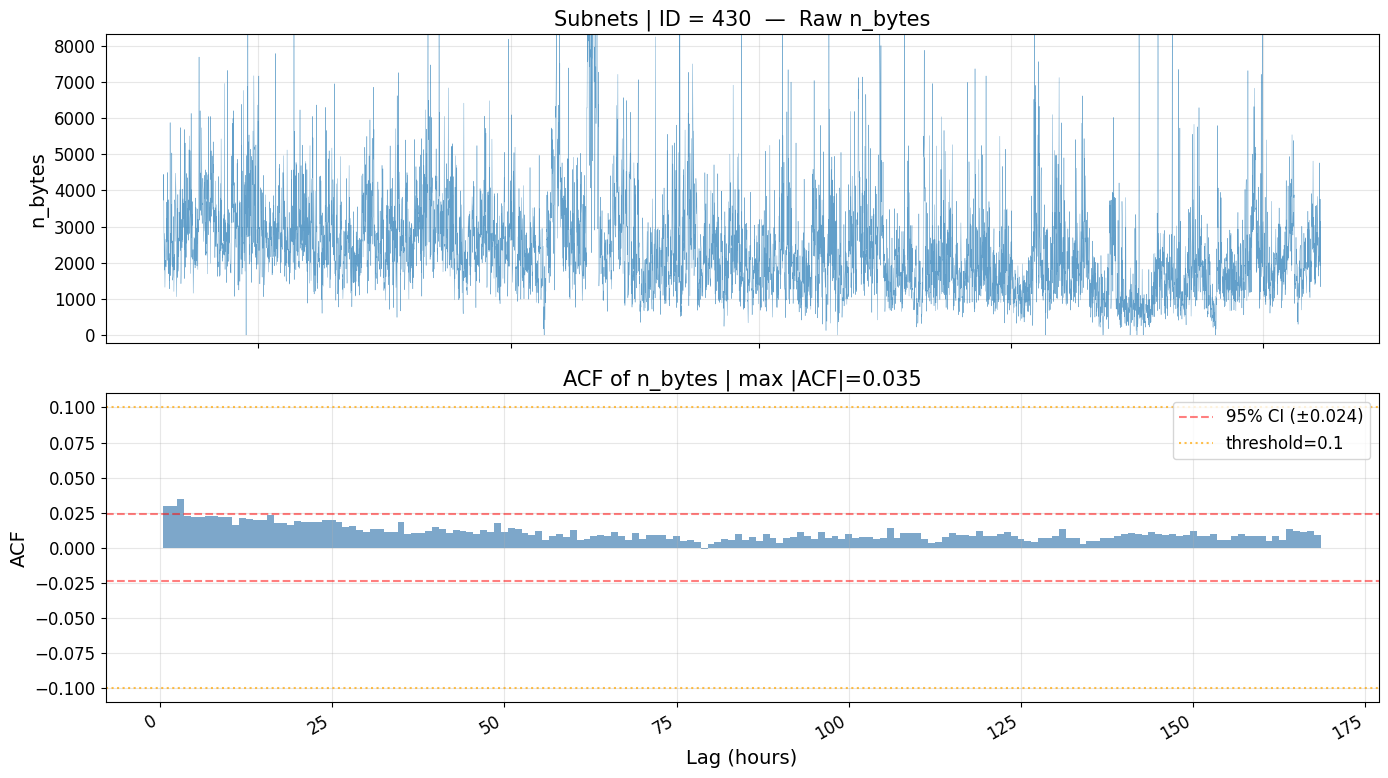

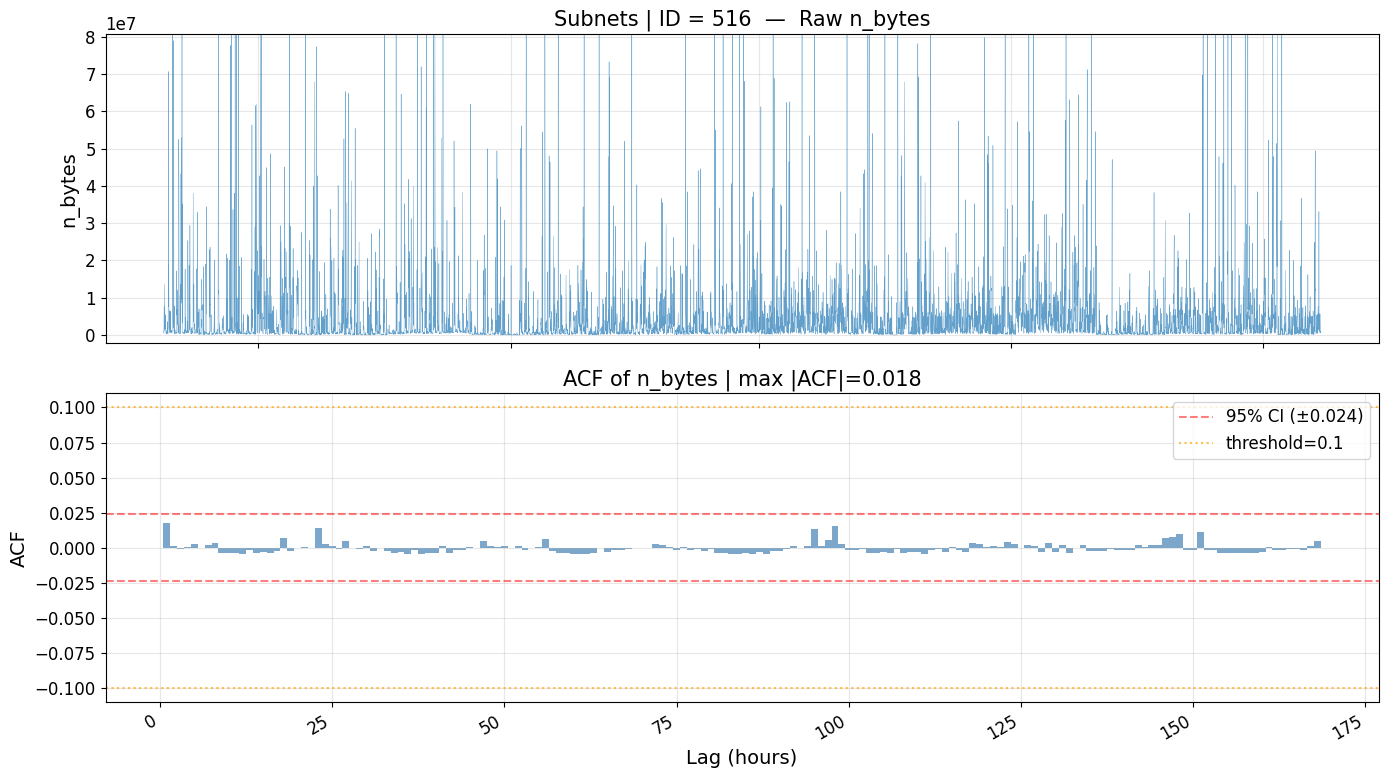

100%|████████████████████████████| 3/3 [00:07<00:00,  2.57s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_SAMPLE

    Time series
        Time series IDS: [ 363446 1604957  488877], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test bat

ips (AGG_1_HOUR): 3 series loaded

IPS — verifying 3 series


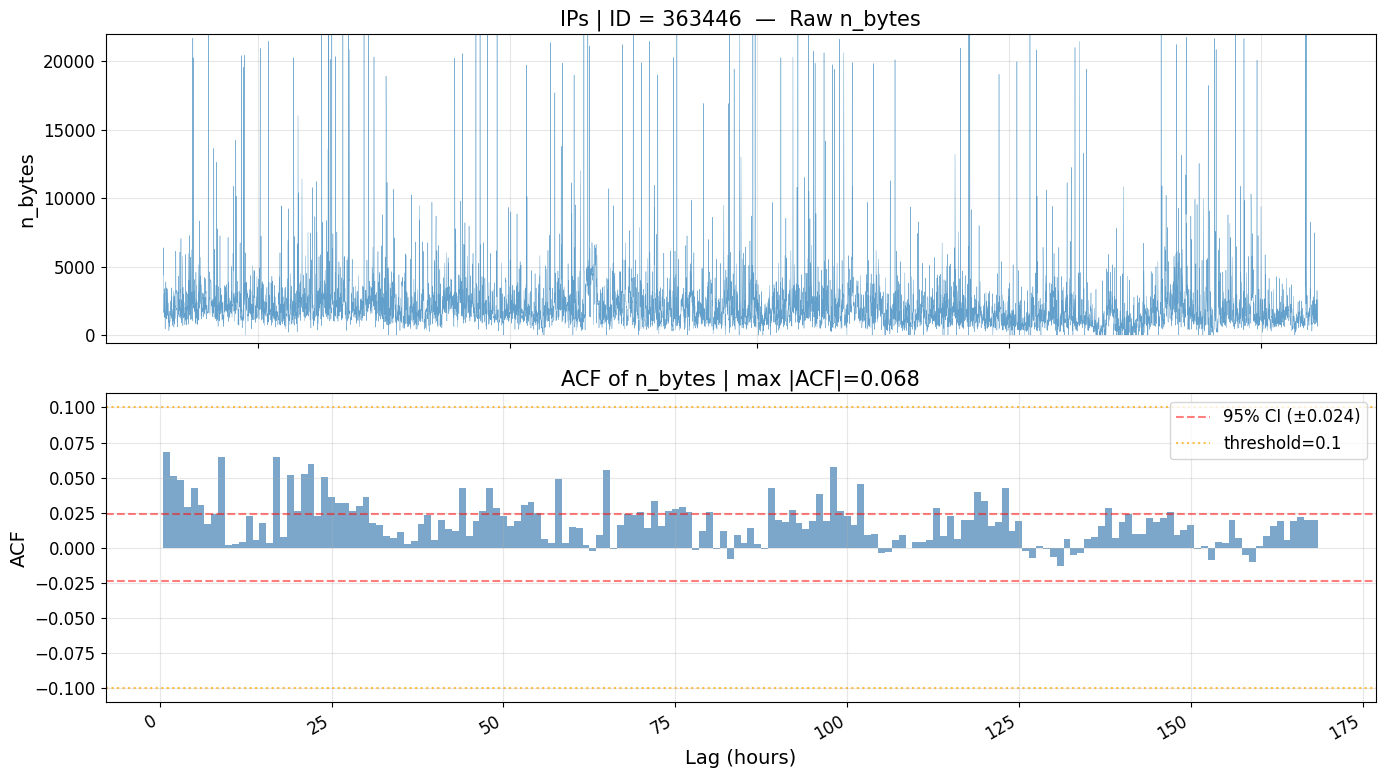

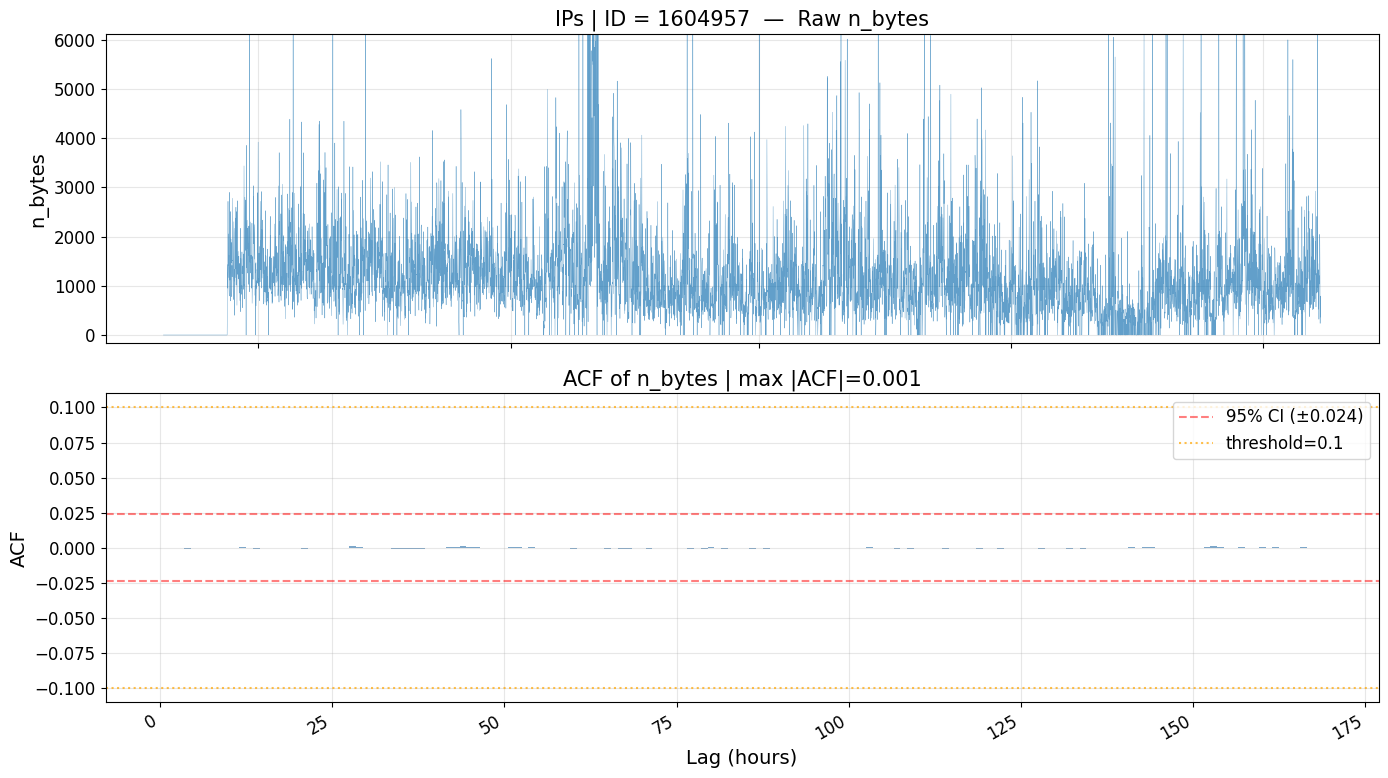

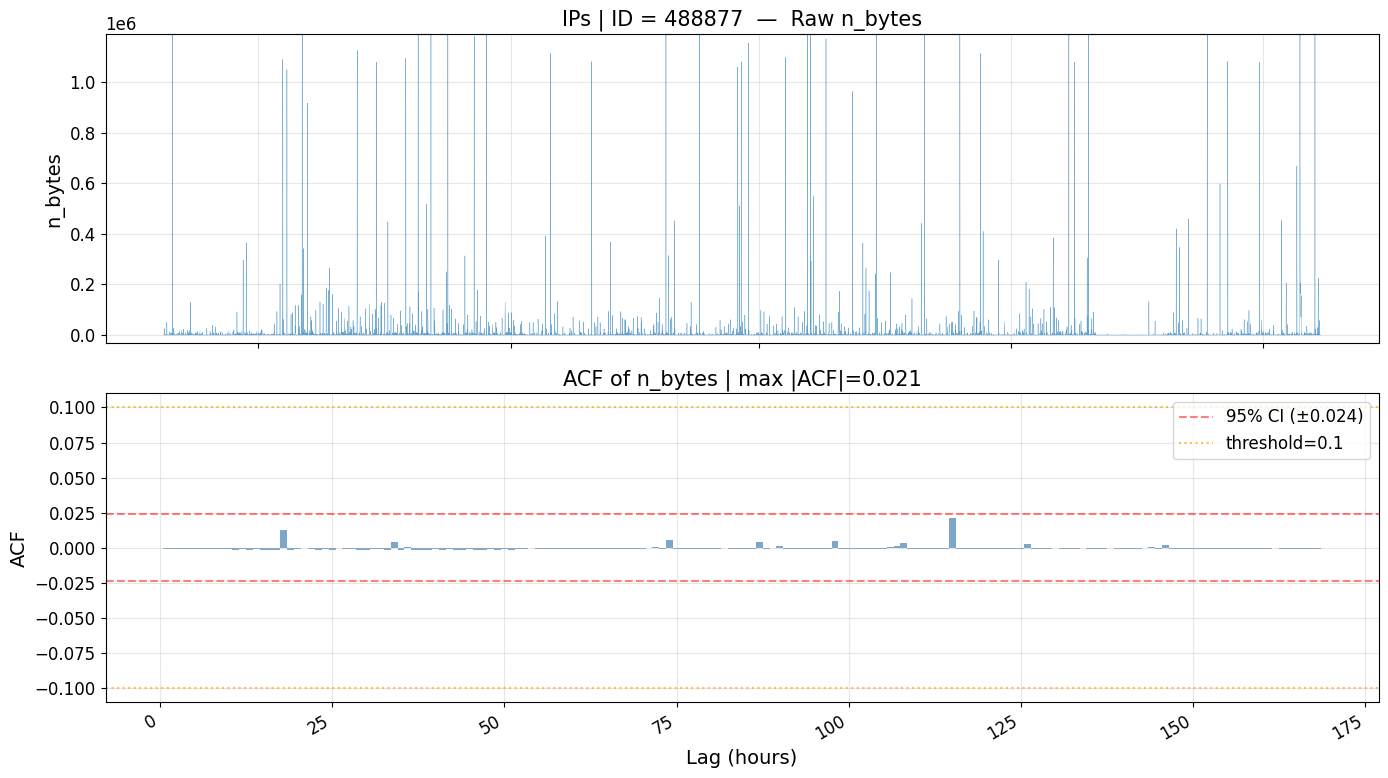

In [7]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)
level_labels = {"institutions": "Institutions", "subnets": "Subnets", "ips": "IPs"}

for source in sources:
    _, id_col = SOURCE_MAP[source]
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    data = load_dataset(source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]
    label = level_labels[source]
    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_random_verification(df, id_col, ts_id, label)

## 6 — Save selection

In [8]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/hourly/RANDOM.csv (63 series)


'selected_ids/hourly/RANDOM.csv'